# Embeddings with the released AION-1 spectrum codec

[AION-1](https://github.com/PolymathicAI/AION) (Parker et al. 2025,
https://arxiv.org/abs/2510.17960) is an omnimodal foundation model: 39
per-modality tokenizers, including `DESISpectrum` and `SDSSSpectrum`, feed a
shared encoder-decoder transformer trained with a masked-modeling objective
across every modality at once. It is too large and dependency-heavy to
reimplement natively in `astrospec` (see `astrospec/pretrained/aion.py`), so
this notebook loads the released checkpoint through the `aion` package
directly. The spectrum modalities take `(flux, ivar, mask, wavelength)`,
this library's own forward-contract keys, on the survey's native pixel
grid; AION's own codec resamples onto its internal latent grid internally, so
no external resampling is needed here, unlike this library's own
fixed/patched-grid models.

The data path is `utils/desi.load_native`: a local MultimodalUniverse DESI EDR SV3 tree if `ASTROSPEC_DESI_ROOT` is set (`healpix=*/` shards), otherwise streaming `ivar`/`mask`/`lambda` straight out of the Hub release's `spectrum` column, which carries them alongside `flux`. Set the variable in a `.env` file in this directory (gitignored; see `examples/README.md`) to avoid exporting it by hand. `utils/__init__.py` loads it automatically.

## Install example-only dependencies

Not part of AstroSpec's core install; only needed for this example. Unlike
AstroCLIP, `aion` installs as a normal package, so it folds into one
`pip install astrospec[aion]`.

In [1]:
!pip install -q h5py matplotlib python-dotenv "astrospec[aion]"

## Imports

In [2]:
import numpy as np
import torch

from astrospec.pretrained import load_pretrained_aion
from utils import desi
from utils.aion import compute_spectrum_embeddings

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load the pretrained AION-1 model

Downloads the released `aion-base` checkpoint once (cached by
`huggingface_hub` afterwards). `codec_manager` turns typed `aion.modalities`
objects into the token dict the transformer expects.

In [3]:
model, codec_manager = load_pretrained_aion("aion-base", device=device)
sum(p.numel() for p in model.parameters())

314255616

## Load spectra

2,000 spectra with their pipeline redshifts, on DESI's native 7,781-pixel
grid, with per-pixel inverse variance and bad-pixel mask. The Hub release
carries neither, so this needs the local tree (`ASTROSPEC_DESI_ROOT`).

In [4]:
flux, ivar, mask, wavelength, z = desi.load_native(2000, redshift=True)
flux.shape, z.min(), z.max()

((2000, 7781), np.float32(-0.0021135716), np.float32(5.807099))

## Embed and search for nearest neighbours

`DESISpectrum` tokenizes each spectrum into 273 tokens; mean-pooling them
gives one embedding per spectrum. As in the other similarity-search
notebooks, embeddings are centered before the cosine so the shared common
component does not dominate every score, and redshift, which the model
never sees, checks whether nearby embeddings are physically similar,
against a random-pair baseline.

In [5]:
embeddings = compute_spectrum_embeddings(model, codec_manager, flux, ivar, mask, wavelength, device)
embeddings = torch.from_numpy(embeddings)
embeddings = torch.nn.functional.normalize(embeddings - embeddings.mean(0, keepdim=True), dim=-1)

similarity = embeddings @ embeddings.T
similarity.fill_diagonal_(-1)
best = similarity.max(-1)
neighbour, neighbour_score = best.indices.numpy(), best.values.numpy()

rng = np.random.default_rng(0)
shuffled = rng.permutation(len(z))
random_score = (embeddings * embeddings[shuffled]).sum(-1).numpy()

print(f"{'':>17}  {'cosine':>8}  {'median |dz|':>12}  {'|dz| < 0.01':>12}")
for name, score, delta in [
    ("nearest neighbour", neighbour_score, np.abs(z - z[neighbour])),
    ("random pair", random_score, np.abs(z - z[shuffled])),
]:
    print(f"{name:>17}  {score.mean():8.3f}  {np.median(delta):12.4f}  {(delta < 0.01).mean():12.3f}")

embedding:   0%|          | 0/125 [00:00<?, ?batch/s]

                     cosine   median |dz|   |dz| < 0.01
nearest neighbour     0.893        0.0198         0.468
      random pair     0.034        0.5851         0.028


## A query and its three nearest neighbours

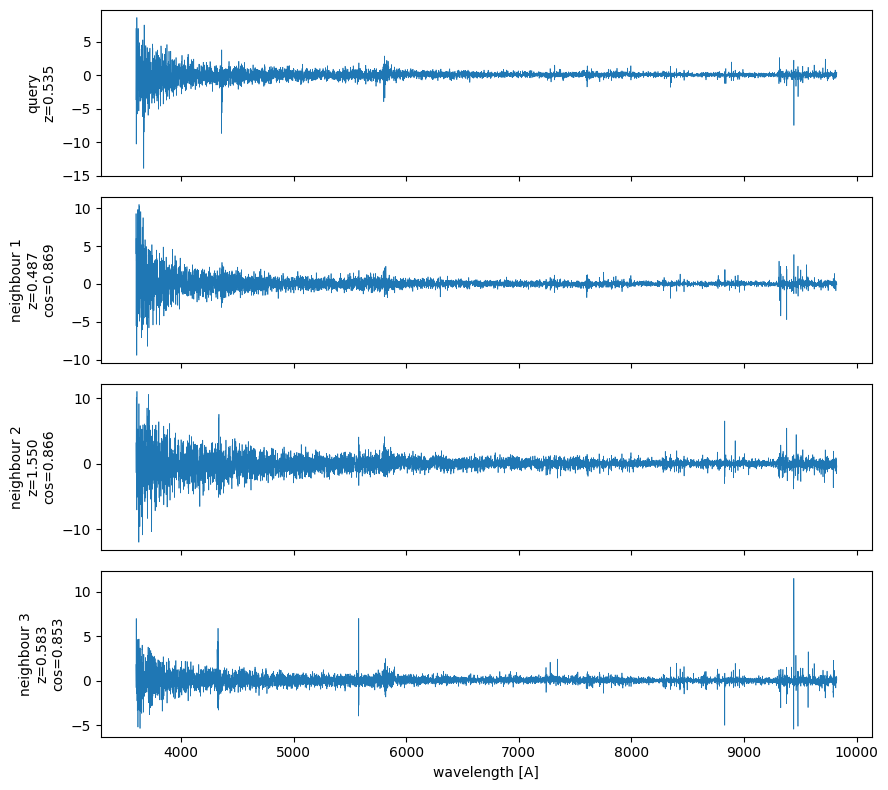

In [6]:
import matplotlib.pyplot as plt

query = int(np.argmax(z > 0.3))
top = similarity[query].topk(3)
panels = [(query, "query", None)] + [
    (int(i), f"neighbour {k + 1}", float(s))
    for k, (i, s) in enumerate(zip(top.indices, top.values))
]

fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)
for ax, (i, title, score) in zip(axes, panels):
    ax.plot(wavelength[i], flux[i], lw=0.5)
    label = f"{title}\nz={z[i]:.3f}"
    ax.set_ylabel(label if score is None else f"{label}\ncos={score:.3f}")
axes[-1].set_xlabel("wavelength [A]")
fig.tight_layout()

## Notes

This is AION-1's own omnimodal embedding, trained across dozens of
modalities rather than aligned spectrum-to-image the way AstroCLIP is.
Compare the retrieval numbers above against
`specformer_pretrained_similarity_search.ipynb`'s and
`astroclip_similarity_search.ipynb`'s: each embedding space was trained with
a different objective (masked-patch reconstruction, CLIP alignment,
omnimodal masked modeling), so none is expected to match another exactly.
`examples/aion_embeddings.ipynb` and `aion_lsdb_embeddings.ipynb` in
AstroLens run the same model's image modality.